In [1]:
""" Find suspension pulses for calibration
Critera:
- must start from ~0 travel
- must reach magnetic interest range within 0.5s

look for pulses of magnet above noise floor lasting <1s
look for zero travel?
"""
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, sosfiltfilt, sosfilt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import random
import scipy
from pathlib import Path
import sys
if __package__ in {None, ""}:
    sys.path.insert(0, str(Path("../").resolve()))
from tools.analyze_accel_mismatch import derive_gt

def print_err_stats(x, gt, prefix=""):
    error = x - gt
    rmse = np.mean(error ** 2) ** 0.5
    mae = np.mean(abs(error))
    me = np.mean(error)
    print(f"{prefix} RMSE: {rmse:.3f}, MAE: {mae:.3f}, ME: {me:.3f}")

In [2]:
def fft_and_histogram(x, fs=100.0, detrend=True, window="hann",
                      hist_bins=80, hist_log=True, eps=1e-12, plot=False):
    """
    x: 1D array of samples (sensor signal)
    fs: sample rate in Hz (100 by default)
    detrend: remove mean to kill DC offset
    window: "hann", "hamming", or None
    hist_bins: number of histogram bins
    hist_log: histogram of log10 magnitudes (usually nicer)
    eps: small number to avoid log(0)
    """
    x = np.asarray(x).astype(float)
    n = x.size

    if detrend:
        x = x - np.mean(x)

    if window is None:
        w = np.ones(n)
    elif window.lower() == "hann":
        w = np.hanning(n)
    elif window.lower() == "hamming":
        w = np.hamming(n)
    else:
        raise ValueError("window must be 'hann', 'hamming', or None")

    xw = x * w

    # One-sided real FFT
    X = np.fft.rfft(xw)
    f = np.fft.rfftfreq(n, d=1.0/fs)

    # Amplitude spectrum (approx. amplitude-corrected for window + one-sided)
    # This gives a reasonable "amplitude per bin" style magnitude.
    # For noise-floor / comparisons, dB is often more informative anyway.
    w_gain = np.sum(w) / n
    mag = (2.0 / n) * np.abs(X) / max(w_gain, eps)
    mag[0] = mag[0] / 2.0  # don't double DC
    if n % 2 == 0:
        mag[-1] = mag[-1] / 2.0  # don't double Nyquist (only if it exists)

    # dB magnitude (optional, handy for plotting)
    mag_db = 20.0 * np.log10(mag + eps)

    if plot:
        # ---- Plot spectrum ----
        plt.figure(figsize=(10,4))
        plt.subplot(1, 2, 1)
        plt.plot(f, mag)  # linear magnitude
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Magnitude")
        plt.title("FFT Magnitude Spectrum (one-sided)")
        plt.grid(True)

        #plt.figure()
        plt.subplot(1, 2, 2)
        plt.plot(f, mag_db)  # dB magnitude
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Magnitude (dB)")
        plt.title("FFT Magnitude Spectrum (dB)")
        plt.grid(True)

        plt.show()

    return f, mag, mag_db

def spectrogram(x, fs, chunk_size, step, plot=True, freq_ds=1, vmax=None):
    #print("X Shape", x.shape)
    n_frames = 1 + (len(x) - chunk_size) // step

    samples = []
    for start in range(0, x.shape[0] - chunk_size, step):
        chunk = x[start:start+chunk_size]
        ff, mag, _ = fft_and_histogram(chunk, fs)
        samples.append(mag)

    tt = (np.arange(n_frames) * step + chunk_size / 2) / fs
    S = np.array(samples).T
    #print("S shape before freq_ds", S.shape)
    if freq_ds > 1:
        n_freq, n_time = S.shape
        n_trim = (n_freq // freq_ds) * freq_ds
        S = S[:n_trim, :]
        S = S.reshape(n_trim // freq_ds, freq_ds, n_time).mean(axis=1)

    S_db = 20.0 * np.log10(S + 1e-12)

    #print(S_db.shape, tt.shape, ff.shape)
    if plot:
        plt.figure(figsize=(10, 5))
        plt.imshow(
            S,
            origin='lower',
            aspect='auto',
            extent=[tt[0], tt[-1], ff[0], ff[-1]],
            vmax=vmax
        )
        plt.xlabel("Time (s)")
        plt.ylabel("Frequency (Hz)")
        plt.title("Spectrogram")
        plt.colorbar(label="Power (dB)")
        plt.tight_layout()
        plt.show()

    return tt, ff, S, S_db

# Example usage:
# x = np.loadtxt("sensor.csv")  # or however you load your data
# f, mag, mag_db = fft_and_histogram(x, fs=100.0)

In [3]:
log_filename = "log112"
out_dir = f"../backend/run_artifacts/{log_filename}/cache/"
ws_file = out_dir + "/all.npz"
ws = np.load(ws_file)
print([str(key) for key in ws.keys()])

t = ws["accel/proj__t"]
a_s2 = ws["accel/lis2__x"]
a_s1 = ws["accel/lis1__x"]
a_proj = ws["accel/proj__x"]
travel = ws["travel__x"][:, 0]
mag_proj = ws["mag/proj/lpf__x"][:, 0]
rel_accel_x = ws["accel/relative__x"][:, 0]
mag_raw = ws["mag__x"]
mag_zv_points = ws["mag_zv_points"]
dense_mag_zv = np.zeros_like(a_s2)
dense_mag_zv[mag_zv_points] = 1
mag_raw_mag = np.linalg.norm(mag_raw, axis=1)
a_s2_x = a_s2[:, 0]
a_s1_x = a_s1[:, 0]
print(a_proj.shape)

['__log_config_hash', 'accel/lis1__t', 'accel/lis1__x', 'accel/lis2__t', 'accel/lis2__x', 'gyro/gyro1__t', 'gyro/gyro1__x', 'gyro/gyro2__t', 'gyro/gyro2__x', 'mag__t', 'mag__x', 'mag_lis__t', 'mag_lis__x', 'angle__t', 'angle__x', 'angle/bad_mask__t', 'angle/bad_mask__x', 'gyro/lpf/gyro1__t', 'gyro/lpf/gyro1__x', 'gyro/lpf/gyro2__t', 'gyro/lpf/gyro2__x', 'accel/lpf/lis1__t', 'accel/lpf/lis1__x', 'accel/lpf/lis2__t', 'accel/lpf/lis2__x', 'lis1_chunks_filt', 'lis2_chunks_filt', 'rotation_matrix', 'accel/lis2_in_lis1__t', 'accel/lis2_in_lis1__x', 'accel/relative__t', 'accel/relative__x', 'accel/lpf/relative__t', 'accel/lpf/relative__x', 'accel_trav_vec', 'mags_vs_means', 'accel/proj__t', 'accel/proj__x', 'accel/lpf/proj__t', 'accel/lpf/proj__x', 'accel/lpfhp/proj__t', 'accel/lpfhp/proj__x', 'angle/lpf__t', 'angle/lpf__x', 'travel__t', 'travel__x', 'boring_mask', 'mag/proj__t', 'mag/proj__x', 'mag/lpf__t', 'mag/lpf__x', 'mag_lis/lpf__t', 'mag_lis/lpf__x', 'mag/proj/lpf__t', 'mag/proj/lpf__x

In [4]:

dt_s = np.diff(t, prepend=t[0]-0.01)

if np.median(dt_s) < 0.007:
    dec = 2
else:
    dec = 1

# Filter accel (HP + LP) 
lp_fc_hz = 20
if dec == 1:
    fs = 100
else:
    fs = 200

sos_lp = butter(N=4, Wn=lp_fc_hz, btype="low", fs=fs, output="sos")
a_s1_x_lp = sosfiltfilt(sos_lp, a_s1_x)
a_s2_x_lp = sosfiltfilt(sos_lp, a_s2_x)
a_proj_lp = sosfiltfilt(sos_lp, a_proj[:, 0])

hp_fc_hz = 1
sos_hp = butter(N=4, Wn=hp_fc_hz, btype="high", fs=fs, output="sos")
a_proj_lhp = sosfiltfilt(sos_hp, a_proj_lp)


print(np.median(dt_s), np.min(dt_s), np.max(dt_s), np.mean(dt_s))
print(dec)
if dec:
    a_s1_x_lp = a_s1_x_lp[::dec]
    a_s2_x_lp = a_s2_x_lp[::dec]
    a_proj_lp = a_proj_lp[::dec]
    a_proj_lhp = a_proj_lhp[::dec]
    a_s1_x = a_s1_x[::dec]
    a_s2_x = a_s2_x[::dec]
    t = t[::dec]
    mag_raw = mag_raw[::dec]
    mag_raw_mag = mag_raw_mag[::dec]
    a_proj = a_proj[::dec]
    rel_accel_x = rel_accel_x[::dec]

dt_s = np.diff(t, prepend=t[0]-0.01)
print(dt_s.shape)
print(travel.shape)
t, a_meas, a_gt, v = derive_gt(ws, use_gradient=True, use_raw=False)
print(dt_s.shape)
print(travel.shape)
print(mag_proj.shape)

0.0049999999999954525 0.004999999999967031 0.010000000000000009 0.0050000395091384636
2
(63277,)
(63277,)
(63277,)
(63277,)
(63277,)


Accel LP RMSE: 0.797, MAE: 0.179, ME: -0.106
GT accel RMSE: 1.930, MAE: 0.550, ME: -0.030


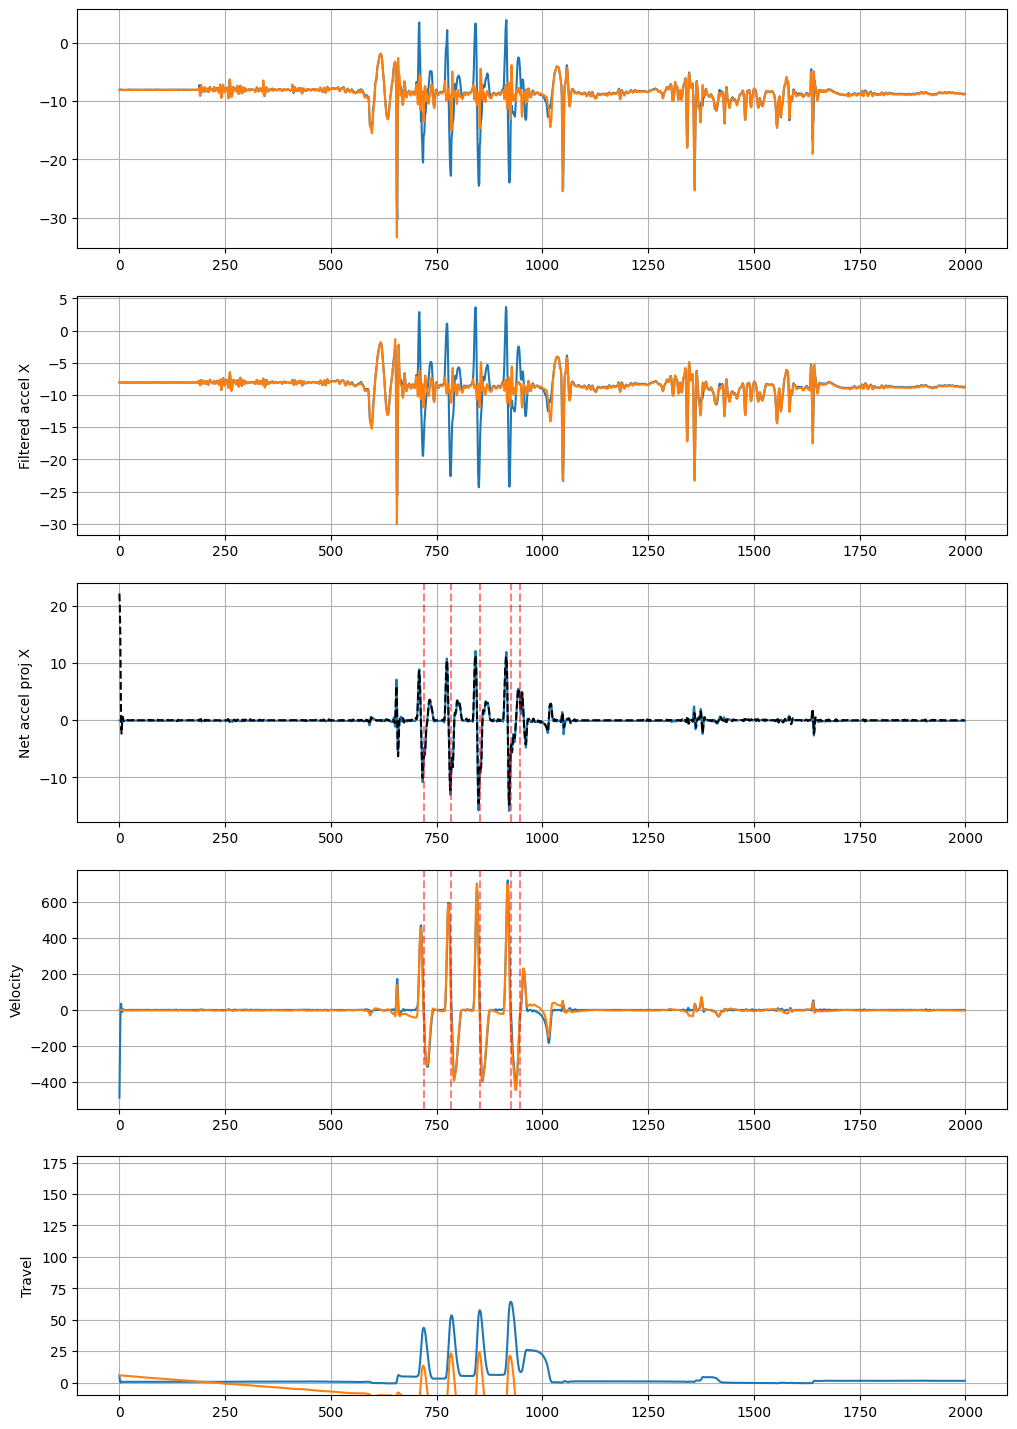

In [5]:
# Plot stuff


#roi = slice(7900, 8500) #log022 cal pulses
#roi = slice(200, 1000) #log049 cal pulse
#roi = slice(39500, 40500) #garbage part of log049
#roi = slice(76950, 77100) # jump in log038
#roi = slice(7750, 18250)# jump in log030
#roi = slice(24800, 25200)
roi = slice(3500, 4000) # log056 cal pulse
roi = slice(0, 2000)

net_accel = a_proj_lhp
a_int_roi = np.cumsum(net_accel[roi] - np.mean(net_accel)) * dt_s[roi] * 1000 # mm/s
a_intint_roi = np.cumsum(a_int_roi) * dt_s[roi] + travel[roi][0]  # mm

plt.figure(figsize=(12, 18))
plt.subplot(5, 1, 1)
#plt.ylabel("Relative accel X")
plt.plot(a_s1_x[roi])
plt.plot(a_s2_x[roi])
plt.grid()

plt.subplot(5, 1, 2)
plt.ylabel("Filtered accel X")
plt.plot(a_s1_x_lp[roi])
plt.plot(a_s2_x_lp[roi])
plt.grid()

plt.subplot(5, 1, 3)
plt.ylabel("Net accel proj X")
#plt.plot(a_proj[roi])
plt.plot(a_proj_lp[roi])
plt.plot(a_gt[roi], label="GT accel", color="k", linestyle="--")
mag_zvs = mag_zv_points - roi.start
for z in mag_zvs:
    if z < 0 or z >= roi.stop - roi.start:
        continue
    plt.axvline(z, color="r", linestyle="--", alpha=0.5)
plt.grid()

acc_err = a_proj_lp[roi] - a_gt[roi]
print_err_stats(a_proj_lp[roi], a_gt[roi], prefix="Accel LP")
print_err_stats(0, a_gt[roi], prefix="GT accel")

plt.subplot(5, 1, 4)
plt.ylabel("Velocity")
plt.plot(v[roi])
plt.plot(a_int_roi)
for z in mag_zvs:
    if z < 0 or z >= roi.stop - roi.start:
        continue
    plt.axvline(z, color="r", linestyle="--", alpha=0.5)
plt.grid()

plt.subplot(5, 1, 5)
plt.ylabel("Travel")
plt.plot(travel[roi])
plt.plot(a_intint_roi)
plt.ylim(-10, 180)
plt.grid(which="both")


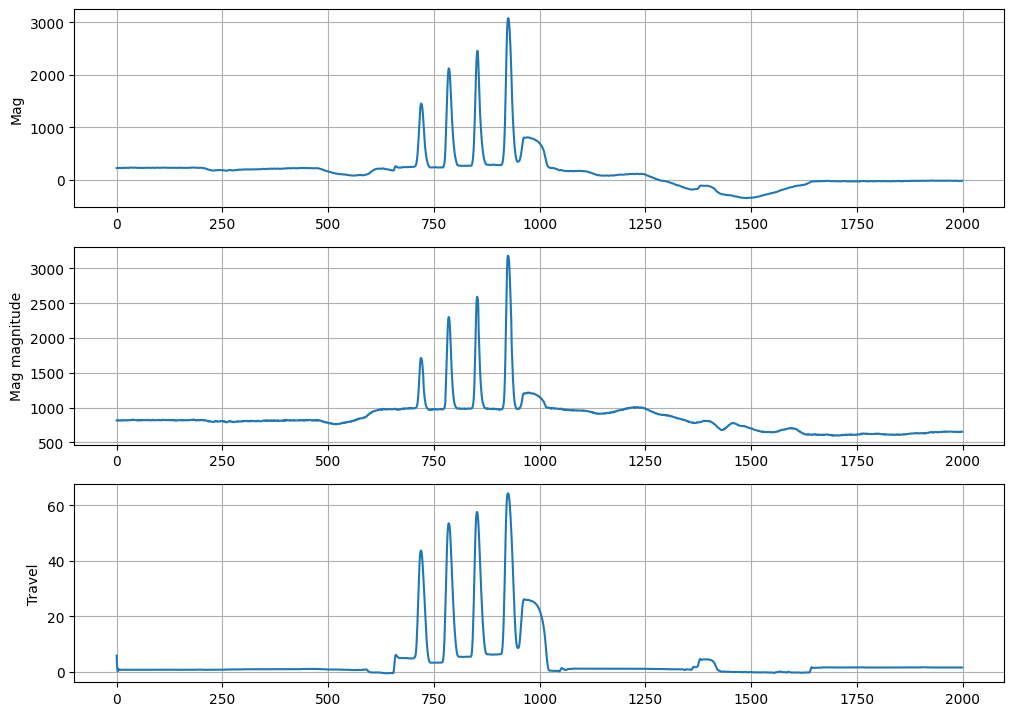

In [6]:
plt.figure(figsize=(12, 18))
plt.subplot(6, 1, 4)
plt.ylabel("Mag")
plt.plot(mag_proj[roi])
plt.grid()
plt.subplot(6, 1, 5)
plt.ylabel("Mag magnitude")
plt.plot(mag_raw_mag[roi])
plt.grid()
plt.subplot(6, 1, 6)
plt.ylabel("Travel")
plt.plot(travel[roi])
plt.grid()

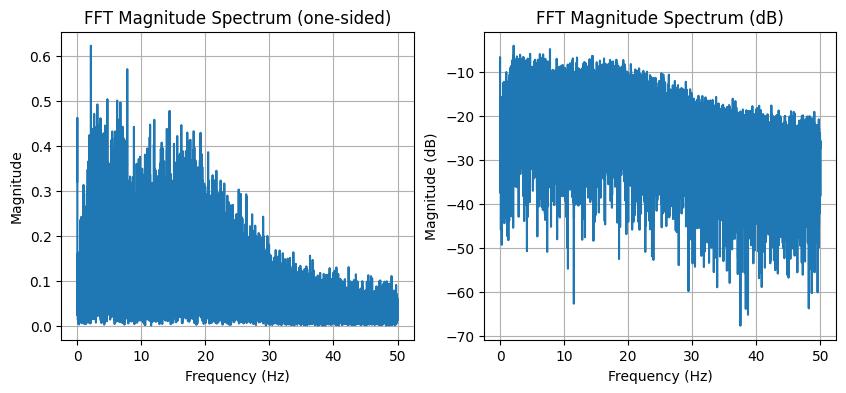

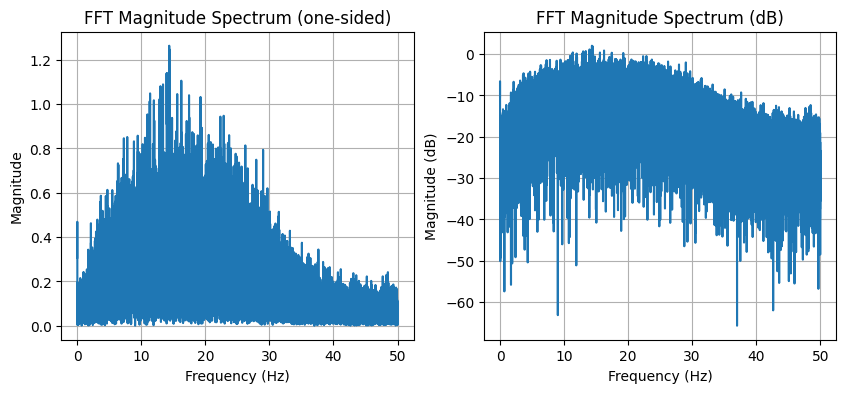

S2 spectrogram


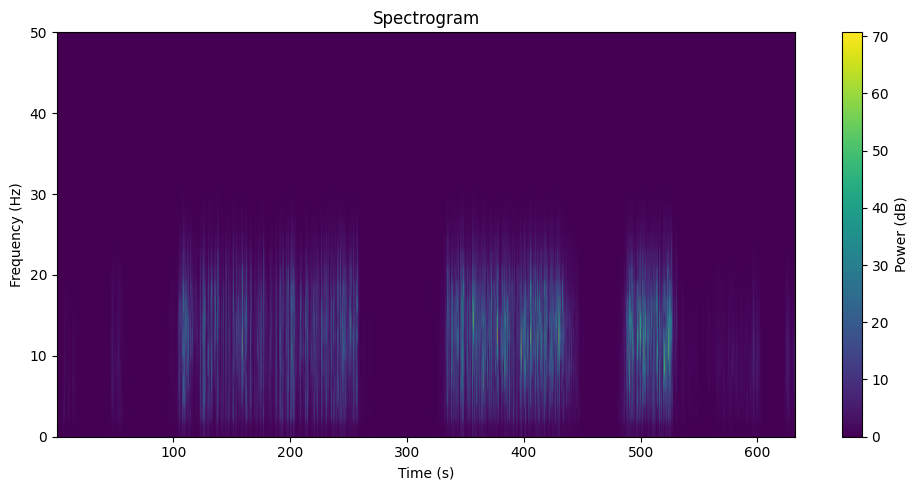

S1 spectrogram


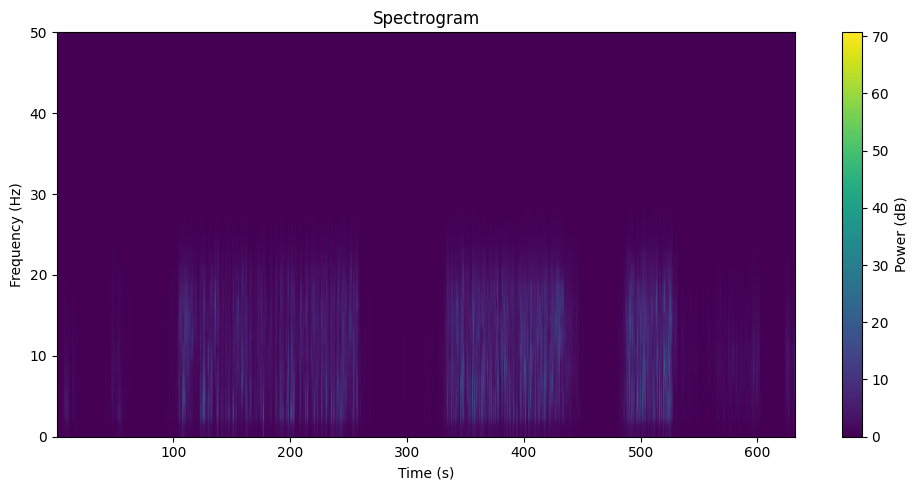

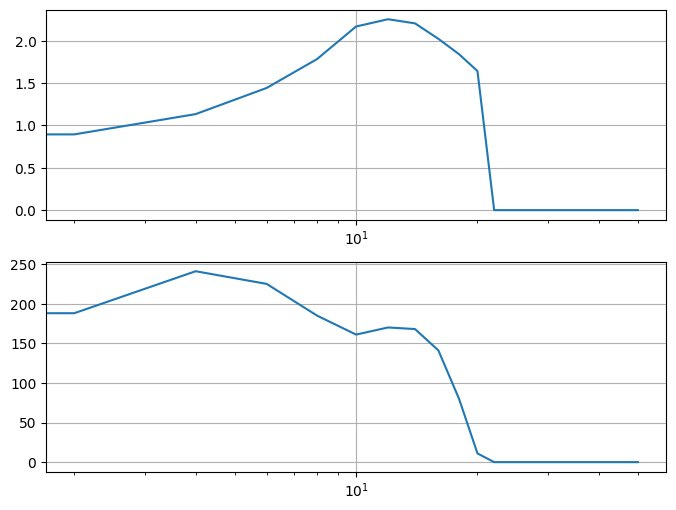

In [7]:
# Frequency domain stuff

fft_and_histogram(a_s1_x, fs=100.0, detrend=True, window="hann",
                  hist_bins=40, hist_log=True, eps=1e-12, plot=True)
fft_and_histogram(a_s2_x, fs=100.0, detrend=True, window="hann",
                  hist_bins=40, hist_log=True, eps=1e-12, plot=True)
roi  = slice(0, -1)
chunk_size = 50
step = 25
print("S2 spectrogram")
_, _, S_s2, S_db_s2 = spectrogram(a_s2_x_lp[roi], fs=100, chunk_size=chunk_size, step=step, freq_ds=1)
print("S1 spectrogram")
tt, ff, S_s1, S_db_s1 = spectrogram(a_s1_x_lp[roi], fs=100, chunk_size=chunk_size, step=step, freq_ds=1, vmax=np.max(S_s2))

# Calculate attenuation by frequency
min_mag = 10
thresh_mask = S_s1 > min_mag
atten = thresh_mask * (S_s2 / (S_s1 + 1e-12))  # very rough estimate of attenuation at each freq/time where accel is strong enough
mask_sum = np.sum(thresh_mask, axis=1)
mean_atten = np.sum(atten, axis=1) / (mask_sum + 1e-12)
plt.figure(figsize=(8, 6))
plt.subplot(2, 1, 1)
plt.semilogx(ff, mean_atten)
plt.grid()
#plt.plot(ff, mean_atten, scaley="log")
plt.subplot(2, 1, 2)
plt.semilogx(ff, mask_sum)#* np.max(mean_atten) / np.max(mask_sum))
plt.grid()

63277
All v 7.998411437891804 220.5259160029973
Still v 0.005976140543133113 4.318504040278189
Still %: 28.77822905637119
Mag baseline 364.857888776491 std 188.84287319123956


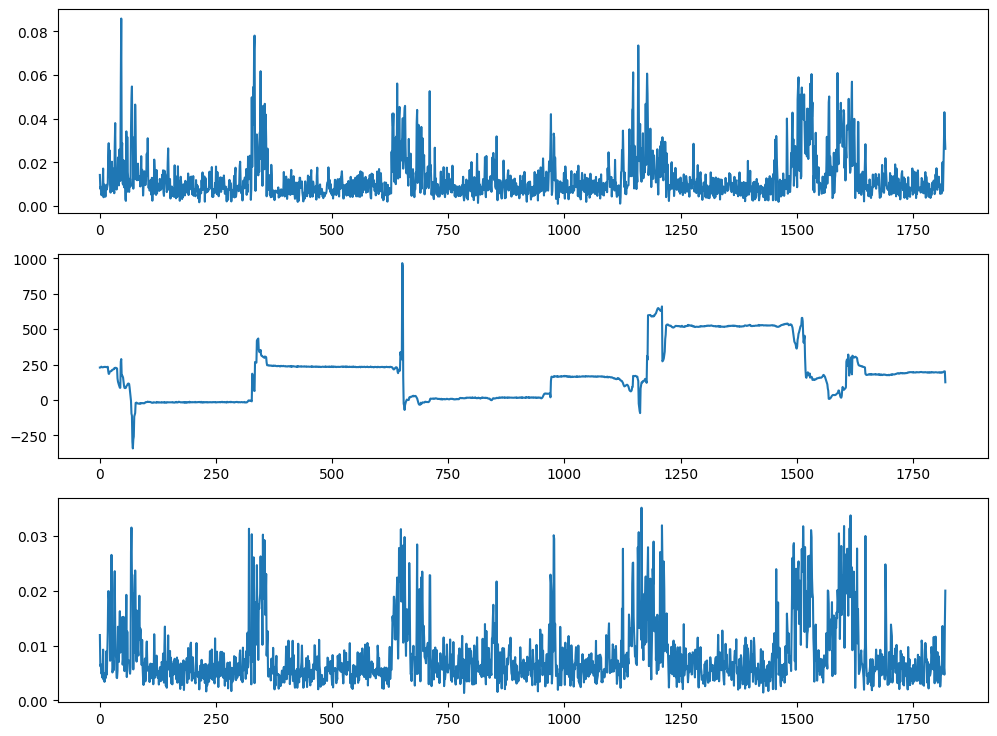

In [8]:
# See how we can identify still sections for mag baseline
still_a_max = 0.1#1
still_len = 10

still_mags = []
still_as = []
still_travs = []
still_vs = []
still_s2 = []
for i in range(0, mag_proj.shape[0] - still_len, still_len):
    mag_chunk = mag_proj[i:i+still_len]
    a_chunk = a_proj_lhp[i:i+still_len]
    a_s2_chunk = np.linalg.norm(a_s1[i*2:(i+still_len)*2], axis=1)
    trav_chunk = travel[i:i+still_len]
    v_chunk = v[i:i+still_len]
    if max(abs(a_chunk)) < still_a_max:
    #if np.std(a_chunk) < still_a_max:
        still_mags.append(mag_chunk)
        still_as.append(abs(a_chunk))
        still_travs.append(trav_chunk)
        still_vs.append(abs(v_chunk))
        still_s2.append(a_s2_chunk)

print(len(v))
print("All v", np.median(abs(v)), np.std(abs(v)))
print("Still v", np.median(still_vs), np.std(still_vs))
print("Still %:", len(still_vs) * still_len / len(v) * 100)

# Set up parameters for finding mag->travel training chunks
mag_baseline = np.median(still_mags) + np.std(still_mags)  # np.percentile(still_mags, 90)#
print("Mag baseline", mag_baseline, "std", np.std(still_mags))
    
plt.figure(figsize=(12,9))
plt.subplot(3, 1, 1)
#plt.plot([np.median(i) for i in still_travs])
plt.plot([np.median(i) for i in still_as])
plt.subplot(3, 1, 2)
plt.plot([np.median(i) for i in still_mags])
plt.subplot(3, 1, 3)
plt.plot([np.std(i) for i in still_as])

In [9]:


# Data parameters
still_v_max = 1e9
bump_x_min = -1
still_mag_max = mag_baseline
bump_mag_min =  1000
still_a_max = 1000
bump_dx_min = 20

# Time parameters
still_len = 10
bump_len = 30
stride = 5
skips = 3 # number of following strides to skip if we find a good one, prevents repeats
chunk_len = still_len + bump_len

-114.33325836198712
slice(680, 720, None) 11.48649282867845 3.249415033979542
5.32157831483828
slice(750, 710, -1) 10.116486703936715 2.5686171579788493
-99.85022570525744
slice(745, 785, None) 13.75349242677158 2.259831802368616
17.201643197014487
slice(820, 780, -1) 13.76577484769544 3.18832955103095
38.39762665622645
slice(810, 850, None) 15.11498360746009 1.6714941234592757
-28.06400239547287
slice(885, 845, -1) 15.355210049722604 4.24879020584031
-84.12463614673979
slice(880, 920, None) 12.455440654654474 2.2916995604917663
-33.718780909321836
slice(10765, 10725, -1) 33.6447299332937 33.053619538533496
-257.42675939200734
slice(19025, 18985, -1) 8.626175281353756 8.499470095430915
10.168189249893464
slice(26025, 25985, -1) 2.85244476328522 1.3773924574012106
-259.17261295142754
slice(51035, 50995, -1) 12.706946159093246 12.326466111772856
Median start v -8.883442620805397 std 21.375590705235744
Median start mag 244.82706749911856 std 106.42499904163421
11 chunks, 30 samples per ch

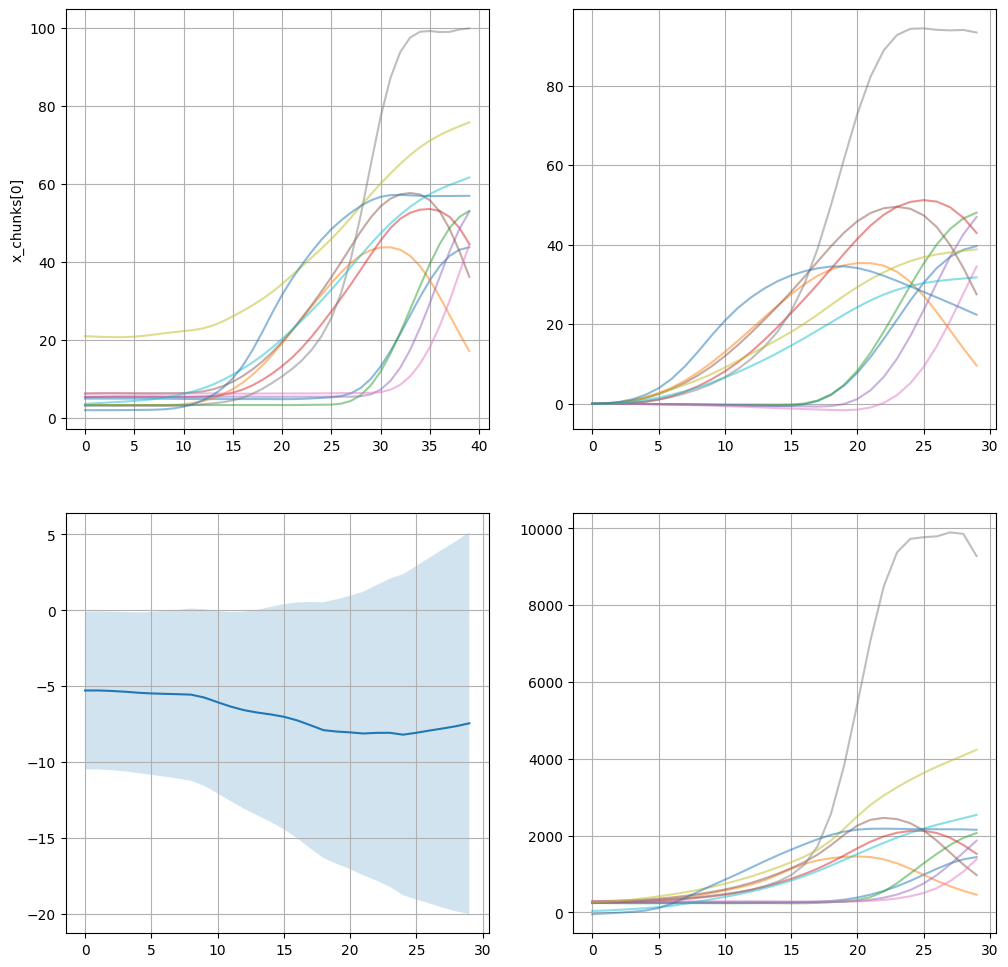

In [10]:
# Find the chunks
a_mms = a_proj_lhp * 1000
still_slice = slice(0, still_len)
bump_slice = slice(still_len, still_len + bump_len)

slices = []
a_intint_chunks = []
i = 0
skip = 0
for i in range(0, travel.shape[0] - chunk_len, stride):
    if skip > 0:
        skip -= 1
        continue

    chunk_r = slice(i, i+chunk_len)
    chunk_l = slice(i+chunk_len, i, -1)
    chunks = [chunk_r, chunk_l]
    
    for chunk_i in chunks: 
        v_still = v[chunk_i][still_slice]
        mag_still = mag_proj[chunk_i][still_slice]
        a_still = a_mms[chunk_i][still_slice]
        a_s1_still = a_s1_x_lp[chunk_i][still_slice]
        a_s2_still = a_s2_x_lp[chunk_i][still_slice]

        a_bump = a_mms[chunk_i][bump_slice]
        t_bump = t[chunk_i][bump_slice]
        x_bump = travel[chunk_i][bump_slice]
        mag_bump = mag_proj[chunk_i][bump_slice]
        a_s1_bump = a_s1_x_lp[chunk_i][bump_slice]
        a_s2_bump = a_s2_x_lp[chunk_i][bump_slice]

        mag_still_mean = np.mean(mag_still)

        if max(abs(v_still)) > still_v_max:
            continue
        if (max(x_bump) - min(x_bump)) < bump_x_min:
            continue
        if np.mean(mag_still) > still_mag_max:
            continue
        if max(abs(a_still)) > still_a_max:
            continue
        if max(mag_bump) < mag_still_mean + bump_mag_min:
            continue
        #print(f"Found bump at index {i}, still mean mag {mag_still_mean:.1f}, bump max mag {max(mag_bump)}")
        
        #a_int = np.cumsum(a_bump * dt_bump)
        #a_intint = np.cumsum(a_int * dt_bump)
        a_corr = max(0.0, np.mean(a_still))
        a_int = scipy.integrate.cumulative_trapezoid(a_bump, t_bump, initial=0)
        a_intint = scipy.integrate.cumulative_trapezoid(a_int, t_bump, initial=0)
        
        s1_still_mean = np.mean(a_s1_still)
        s2_still_mean = np.mean(a_s2_still)
        s1_max = np.max(np.abs(a_s1_bump - s1_still_mean))
        s2_max = np.max(np.abs(a_s2_bump - s2_still_mean))
        if (s2_max > s1_max):
            continue

        if max(a_intint) < bump_dx_min:
            continue

        skip = skips

        print(np.mean(a_still))
        print(chunk_i, s1_max, s2_max)
        a_intint_chunks.append(a_intint)
        slices.append(chunk_i)

x_chunks = [travel[chunk_i][bump_slice] for chunk_i in slices]
mag_chunks = [mag_proj[chunk_i][bump_slice] for chunk_i in slices]
start_vs = [v[chunk_i][bump_slice][0] for chunk_i in slices]
start_mags = [mag_chunk[0] for mag_chunk in mag_chunks]
print("Median start v", np.median(start_vs), "std", np.std(start_vs))
print("Median start mag", np.median(start_mags), "std", np.std(start_mags))
#x_chunks -= np.mean([x_chunk[0] for x_chunk in x_chunks], axis=0)  # remove mean to align better

errors = [a_intint - x_chunk for x_chunk, a_intint in zip(x_chunks, a_intint_chunks)]
err_arr = np.asarray(errors)
print(err_arr.shape[0], "chunks,", err_arr.shape[1], "samples per chunk")
error_avg = np.median(err_arr, axis=0)
error_std = np.std(err_arr, axis=0)
print(error_avg.shape)
travel_avg = np.median([abs(chunk_i) for chunk_i in x_chunks], axis=0)
trav_std = np.std([abs(chunk_i) for chunk_i in x_chunks], axis=0)

peak_idxs = [np.argmax(a_intint_chunk) for a_intint_chunk in a_intint_chunks]
peak_errs = [a_intint_chunk[peak_idx] - x_chunk[peak_idx] for a_intint_chunk, x_chunk, peak_idx in zip(a_intint_chunks, x_chunks, peak_idxs)]
print(peak_errs)

mean_end_error = error_avg[-1]
mean_end_travel = travel_avg[-1]
print(f"Median end error: {mean_end_error:.2f} mm, median end travel: {mean_end_travel:.2f} mm")
print(f"Median start error: {error_avg[0]:.2f} mm, median start travel: {travel_avg[0]:.2f} mm")
print(f"Ratio of median end error to median end travel: {mean_end_error / mean_end_travel:.2%}")

print(slices)

plt.figure(figsize=(12, 12))
plt.subplot(2, 2, 1)
plt.ylabel("x_chunks[0]")
for i in range(len(x_chunks)):
    plt.plot(travel[slices[i]], alpha=0.5)
plt.grid()
plt.subplot(2, 2, 2)
for i in range(len(x_chunks)):
    plt.plot(a_intint_chunks[i], alpha=0.5)
plt.grid()
plt.subplot(2, 2, 3)
plt.plot(error_avg)
plt.fill_between(range(len(error_avg)), error_avg - error_std, error_avg + error_std, alpha=0.2)
plt.grid()
plt.subplot(2, 2, 4)
for i in range(len(mag_chunks)):
    plt.plot(mag_chunks[i], alpha=0.5)
plt.grid()

In [11]:
# Concatenate chunks to points
mag_points = np.concatenate(mag_chunks)
pred_x_points = np.concatenate(a_intint_chunks)
x_points = np.concatenate(x_chunks)

mag_center = mag_baseline + 2000
center_range = 1000
thresh_mask = (mag_points > mag_center - center_range) & (mag_points < mag_center + center_range)
print(f"Using {np.sum(thresh_mask)} points within mag range {mag_center - center_range} to {mag_center + center_range} for position error stats")
print(np.median(pred_x_points[thresh_mask]))
print(np.median(x_points[thresh_mask]))

Using 73 points within mag range 1364.857888776491 to 3364.857888776491 for position error stats
34.61125154099735
52.84080649722992


In [12]:
# Filter data from chunks with mag bounds
mag_lower_thresh = mag_baseline + 1000
mag_upper_thresh = mag_lower_thresh + 2000 #np.percentile(mag_points[mag_points > mag_lower_thresh], 80)
print("Mag min", mag_lower_thresh, "Max", mag_upper_thresh)

mag_mask = (mag_points > mag_lower_thresh) * (mag_points < mag_upper_thresh)
mag_points_filtered = mag_points[mag_mask]
pred_x_points_filtered = pred_x_points[mag_mask]
x_points_filtered = x_points[mag_mask]

chunks_filt = []
for (mag_chunk, a_intint) in zip(mag_chunks, a_intint_chunks):
    mask_i = (mag_chunk > mag_lower_thresh) * (mag_chunk < mag_upper_thresh)
    if len(a_intint[mask_i]) > 0:
        chunks_filt.append((mag_chunk[mask_i], a_intint[mask_i]))

print([len(mag_chunk) for mag_chunk, _ in chunks_filt])
print("Unfiltered chunks", len(mag_chunks), "Filtered chunks", len(chunks_filt))
print("Unfiltered points", mag_points.shape, "Filtered points", mag_points_filtered.shape)


Mag min 1364.857888776491 Max 3364.857888776491
[2, 5, 4, 11, 2, 11, 1, 2, 8, 11, 16]
Unfiltered chunks 11 Filtered chunks 11
Unfiltered points (330,) Filtered points (73,)


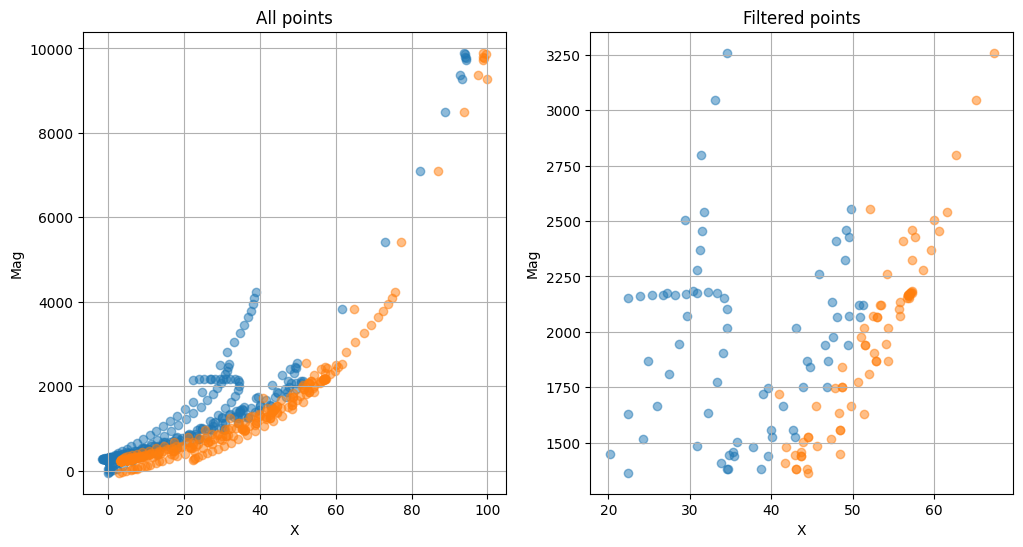

In [13]:
# Plot results of filtering points by mag
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.scatter(pred_x_points, mag_points, alpha=0.5)
plt.scatter(x_points, mag_points, alpha=0.5)
plt.ylabel("Mag")
plt.xlabel("X")
plt.title("All points")
plt.grid()
plt.subplot(1, 2, 2)
plt.scatter(pred_x_points_filtered, mag_points_filtered, alpha=0.5)
plt.scatter(x_points_filtered, mag_points_filtered, alpha=0.5)
plt.ylabel("Mag")
plt.xlabel("X")
plt.title("Filtered points")
plt.grid()

[33.71507297 37.9824006  32.2199227  39.31710016 39.28755565 43.30874435
 32.99595823 38.37297145 44.4387291  35.45676608]
[5.31660888 6.95578043 7.28563367 6.87950036 9.19371787 7.56720022
 8.78438773 7.53256148 7.66319118 7.97926892]
65
Mean std across bins 7.51578507236466


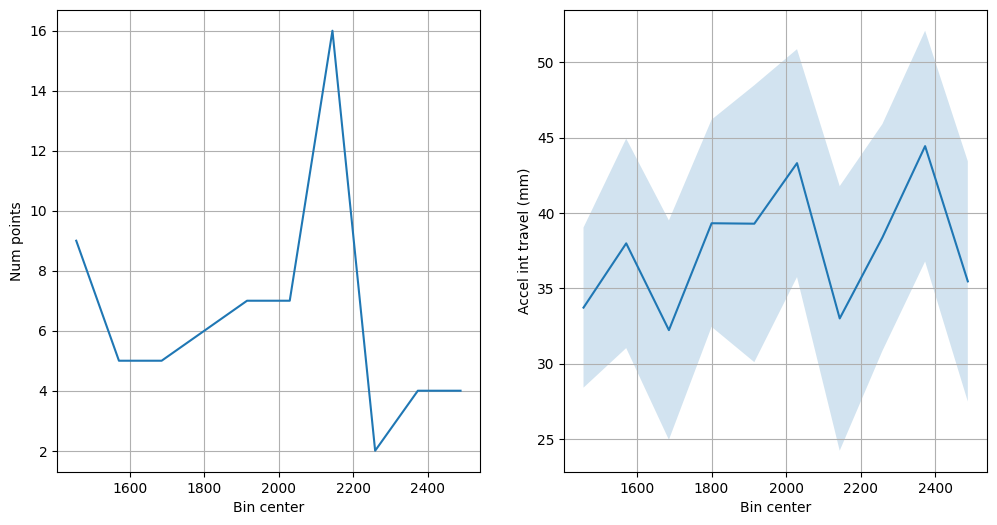

In [14]:
# Bin points by mag and get stats
n_bins = 10

#mags_i = mag_points
#x_i = pred_x_points
mags_i = mag_points_filtered
x_i = pred_x_points_filtered

mag_max = np.percentile(mags_i, 95)
mag_min = np.percentile(mags_i, 5)
bin_size = (mag_max - mag_min) / n_bins

bins = []
for i in range(n_bins):
    bin_min = mag_min + (bin_size * i)
    bin_max = mag_min + (bin_size * (i + 1))

    mask = (mags_i > bin_min) * (mags_i <= bin_max)
    x_masked = x_i[mask]
    mag_masked = mags_i[mask]
    bins.append(x_masked)

bin_centers = [((i + 0.5) * bin_size + mag_min) for i in range(n_bins)]
bin_stds = np.asarray([np.std(bin) for bin in bins])
bin_means = np.asarray([np.mean(bin) for bin in bins])
print(bin_means)
print(bin_stds)
print(np.sum([bins[i].shape[0] for i in range(n_bins)]))

mean_bin_std = np.mean(bin_stds)
print("Mean std across bins", mean_bin_std)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(bin_centers, [bins[i].shape[0] for i in range(n_bins)])
plt.ylabel("Num points")
plt.xlabel("Bin center")
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(bin_centers, bin_means)
plt.fill_between(bin_centers, bin_means - bin_stds, bin_means + bin_stds, alpha=0.2)
plt.ylabel("Accel int travel (mm)")
plt.xlabel("Bin center")
plt.grid()


Outlier distance threshold 3.75789253618233
(73,)
best_inliers 3
[0.        0.0018196] 33.0497120216563


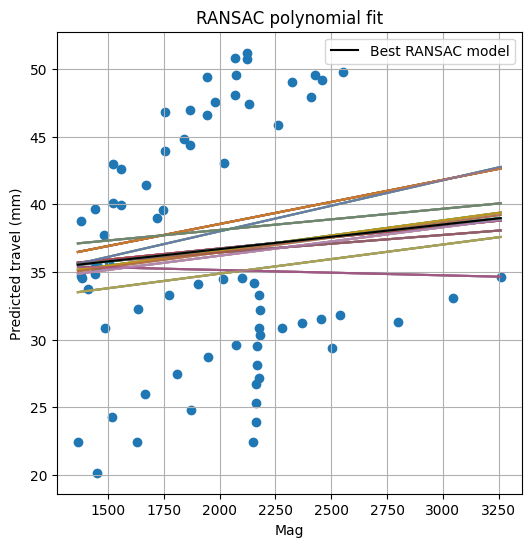

In [15]:
# RANSAC
k = 10
n_iter = 100
outlier_dist = mean_bin_std * 0.5
print("Outlier distance threshold", outlier_dist)
poly_degree = 1

mag_points_all = np.concatenate([chunk_i[0] for chunk_i in chunks_filt])
x_points_all = np.concatenate([chunk_i[1] for chunk_i in chunks_filt])
print(mag_points_all.shape)

plt.figure(figsize=(6, 6))
plt.scatter(mag_points_all, x_points_all)
best_model = None
best_inliers = None
for i in range(n_iter):
    sampled_chunks = random.sample(chunks_filt, k)
    mag_points_i = np.concatenate([chunk_i[0] for chunk_i in sampled_chunks])
    x_points_i = np.concatenate([chunk_i[1] for chunk_i in sampled_chunks])

    # Train on just the sampled chunks
    poly = PolynomialFeatures(degree=poly_degree)
    X_poly = poly.fit_transform(mag_points_i.reshape(-1, 1))
    model = LinearRegression()
    model.fit(X_poly, x_points_i)

    # Predict on all points in the set
    mag_poly = poly.fit_transform(mag_points_all.reshape(-1, 1))
    model_preds = model.predict(mag_poly)

    # Find inlier chunks based on distance to model
    n_inliers = 0
    for chunk_i in chunks_filt:
        mag_chunk = chunk_i[0]
        x_chunk = chunk_i[1]
        mag_chunk_poly = poly.fit_transform(mag_chunk.reshape(-1, 1))
        preds_chunk = model.predict(mag_chunk_poly)
        dist = np.sqrt(np.mean((preds_chunk - x_chunk) ** 2))
        if dist < outlier_dist:
            n_inliers += 1#preds_chunk.shape[0]

    if best_inliers is None or n_inliers > best_inliers:
        best_inliers = n_inliers
        best_model = model

    preds_sorted_by_mag = model_preds[np.argsort(mag_points_all)]
    mag_sorted = mag_points_all[np.argsort(mag_points_all)]
    plt.plot(mag_sorted, preds_sorted_by_mag, alpha=0.5)

print("best_inliers", best_inliers)
print(model.coef_, model.intercept_)

mag_poly = poly.fit_transform(mag_points_all.reshape(-1, 1))
best_model_preds = best_model.predict(mag_poly)
plt.plot(mag_sorted, best_model_preds[np.argsort(mag_points_all)], color="black", label="Best RANSAC model")
plt.legend()
plt.xlabel("Mag")
plt.ylabel("Predicted travel (mm)")
plt.title("RANSAC polynomial fit")
plt.grid()

In [16]:
fit_x_points = mag_points_filtered
fit_y_points = pred_x_points_filtered
#fit_x_points = mag_points
#fit_y_points = pred_x_points
#fit_x_points = np.asarray(med_filt_mag)
#fit_y_points = np.asarray(med_filt_x)
#fit_x_points = mag_proj
#fit_y_points = travel

poly = PolynomialFeatures(degree=poly_degree)
X_poly = poly.fit_transform(fit_x_points.reshape(-1, 1))
model = LinearRegression()
model.fit(X_poly, fit_y_points)
mag_poly = poly.fit_transform(mag_points.reshape(-1, 1))

#best_model = model

(63277,) (63277,) (63277,)
Mag to travel fit RMSE: 21.521, MAE: 20.364, ME: -20.364
Mag to travel fit (filtered) RMSE: 16.432, MAE: 15.551, ME: -15.551
Centered mag to travel fit (filtered) RMSE: 5.306, MAE: 4.403, ME: -0.000
Mag to travel fit (filtered) to accel-int travel RMSE: 8.538, MAE: 7.455, ME: 0.014


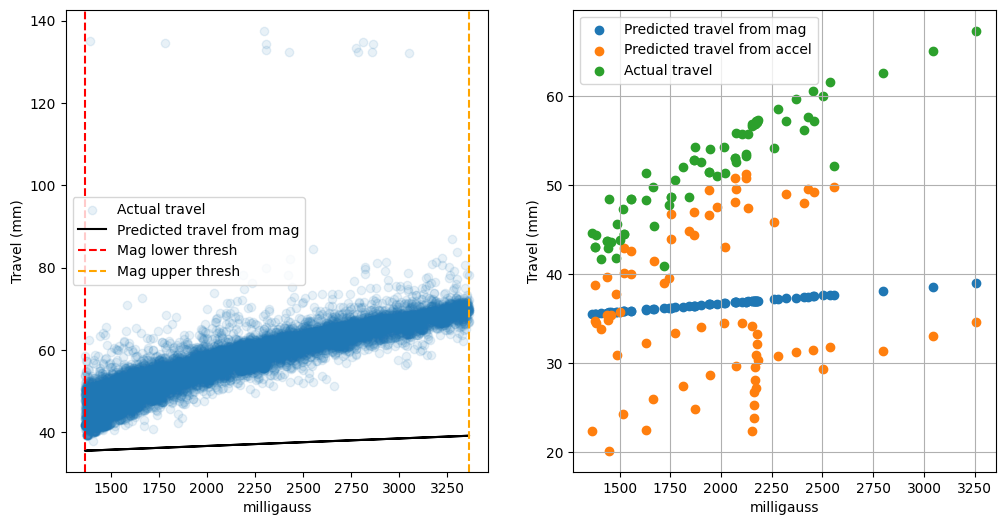

In [17]:
travel_filtered_preds = best_model.predict(mag_poly[mag_mask])
travel_preds = best_model.predict(mag_poly)

plt.figure(figsize=(12,6))

all_mag_mask = (mag_proj > mag_lower_thresh) * (mag_proj < mag_upper_thresh)
all_mag_poly = poly.fit_transform(mag_proj[all_mag_mask].reshape(-1, 1))
all_travel_preds = best_model.predict(all_mag_poly)
print(all_mag_mask.shape, mag_proj.shape, travel.shape)

plt.subplot(1, 2, 1)
plt.scatter(mag_proj[all_mag_mask], travel[all_mag_mask], label="Actual travel", alpha=0.1)
plt.plot(mag_proj[all_mag_mask], all_travel_preds, alpha=1, label="Predicted travel from mag", color="black")
plt.axvline(mag_lower_thresh, color="red", linestyle="--", label="Mag lower thresh")
plt.axvline(mag_upper_thresh, color="orange", linestyle="--", label="Mag upper thresh")
plt.xlabel("milligauss")
plt.ylabel("Travel (mm)")
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(mag_points_filtered, travel_filtered_preds, label="Predicted travel from mag")
plt.scatter(mag_points_filtered, pred_x_points_filtered, label="Predicted travel from accel")
plt.scatter(mag_points_filtered, x_points_filtered, label="Actual travel")
plt.xlabel("milligauss")
plt.ylabel("Travel (mm)")
plt.grid()
plt.legend()

centered_trav_filt_preds = travel_filtered_preds - np.mean(travel_filtered_preds)
centered_x_points_filtered = x_points_filtered - np.mean(x_points_filtered)

print_err_stats(all_travel_preds, travel[all_mag_mask], prefix="Mag to travel fit")
print_err_stats(travel_filtered_preds, x_points_filtered, prefix="Mag to travel fit (filtered)")
print_err_stats(centered_trav_filt_preds, centered_x_points_filtered, prefix="Centered mag to travel fit (filtered)")
print_err_stats(travel_filtered_preds, pred_x_points_filtered, prefix="Mag to travel fit (filtered) to accel-int travel")


[(8, np.float64(75.57991501201435)), (5, np.float64(86.97383372762671)), (9, np.float64(89.78480569933427)), (10, np.float64(101.99211406639569)), (3, np.float64(112.11280585091725))]


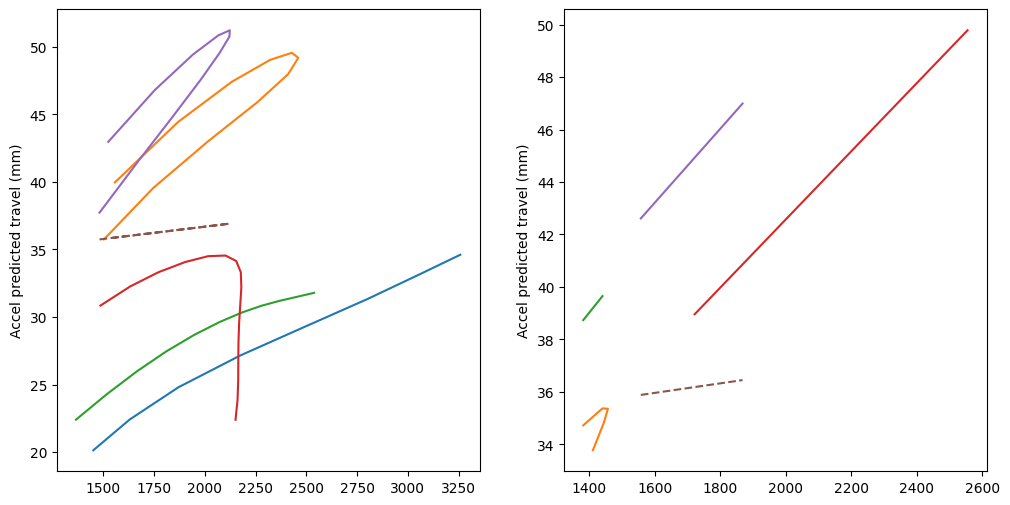

In [18]:
# Find the chunks contributing the most to the error

pred_errors = []
y_preds = []
mags = []
a_ints = []
for (mag_chunk, a_int_chunk) in zip(mag_chunks, a_intint_chunks):
    mag_mask_i = (mag_chunk > mag_lower_thresh) * (mag_chunk < mag_upper_thresh)
    if np.where(mag_mask_i)[0].size > 0:
        x_poly = poly.fit_transform(mag_chunk[mag_mask_i].reshape(-1, 1))
        y_pred = best_model.predict(x_poly)
        pred_error = abs(a_int_chunk[mag_mask_i] - y_pred)
        mean_err = np.sum(pred_error)

        pred_errors.append(mean_err)
        y_preds.append(y_pred)
        mags.append(mag_chunk[mag_mask_i])
        a_ints.append(a_int_chunk[mag_mask_i])

errors_sorted = sorted(enumerate(pred_errors), key=lambda x: x[1])
print(errors_sorted[-5:])

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.ylabel("Accel predicted travel (mm)")
for i in errors_sorted[-5:]:
    chunk_idx = i[0]
    plt.plot(mags[chunk_idx], a_ints[chunk_idx])
plt.plot(mags[chunk_idx], y_preds[chunk_idx], linestyle="--")
plt.subplot(1, 2, 2)
plt.ylabel("Accel predicted travel (mm)")
for i in errors_sorted[:5]:
    chunk_idx = i[0]
    plt.plot(mags[chunk_idx], a_ints[chunk_idx])
plt.plot(mags[chunk_idx], y_preds[chunk_idx], linestyle="--")


In [19]:
# Find the worst chunks
errors_sorted = sorted(enumerate(slices), key=lambda x: abs_err_arr[x[0]][-1])

num_worst = len(errors_sorted) // 4

worst_slices = [x[1] for x in errors_sorted][-num_worst:]
worst_indices = [x[0] for x in errors_sorted][-num_worst:]
print(worst_indices)

ok_slices = [x[1] for x in errors_sorted][:-num_worst]
ok_indices = [x[0] for x in errors_sorted][:-num_worst:]
print(ok_indices)

for indices, name in [(worst_indices, "worst"), (ok_indices, "ok")]:
    print("Mean max pred travel", np.mean([max(a_intint_chunks[i]) for i in indices]))
    print("Mean std accel", np.mean([np.std(a_proj_lhp[slices[i]]) for i in indices]))

worst_mean_end_error = np.mean([abs_err_arr[i][-1] for i in worst_indices])
print(f"Worst mean end error: {worst_mean_end_error:.2f} mm")

plt.figure(figsize=(12, 12))
plt.subplot(2, 2, 1)
plt.ylabel("Absolute error (mm)")
for i in worst_indices:
    plt.plot(abserrors[i])
plt.subplot(2, 2, 2)
plt.ylabel("Magnetic")
for i in worst_indices:
    plt.plot(mag_chunks[i])
plt.subplot(2, 2, 3)
plt.ylabel("Travel (mm)")
for i in worst_indices:
    plt.plot(x_chunks[i])
plt.subplot(2, 2, 4)
plt.ylabel("Integrated acceleration (mm)")
for i in worst_indices:
    plt.plot(a_intint_chunks[i])

NameError: name 'abs_err_arr' is not defined

789.5559028965575 2789.5559028965577 200.0


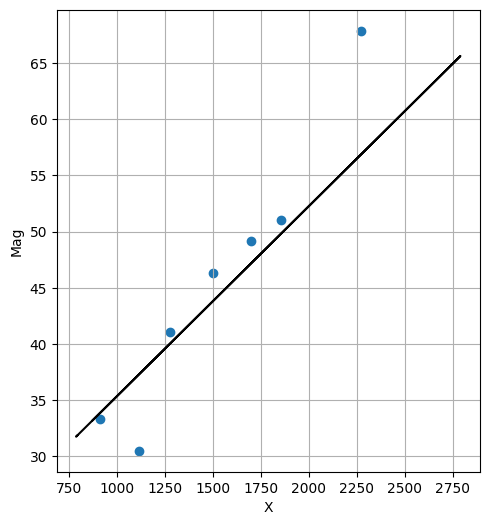

In [ ]:
# Try some point filtering methods 
num_bins = 10
min_bin_points = 5
x_pred_min, x_pred_max = mag_lower_thresh, mag_upper_thresh
bin_size = (x_pred_max - x_pred_min) / num_bins

print(x_pred_min, x_pred_max, bin_size)

med_filt_x = []
med_filt_mag = []
for i in range(num_bins):
    bin_min_x, bin_max_x = (bin_size * i) + x_pred_min, (bin_size * (i + 1)) + x_pred_min
    bin_mask = (mag_points >= bin_min_x) * (mag_points < bin_max_x)
    if np.where(bin_mask)[0].size >= min_bin_points:
        med_x = np.median(pred_x_points[bin_mask])
        med_mag = np.median(mag_points[bin_mask])
        med_filt_x.append(med_x)
        med_filt_mag.append(med_mag)

plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.scatter(med_filt_mag, med_filt_x)
plt.plot(mag_proj[all_mag_mask], all_travel_preds, alpha=1, label="Predicted travel from mag", color="black")
plt.ylabel("Mag")
plt.xlabel("X")
plt.grid()

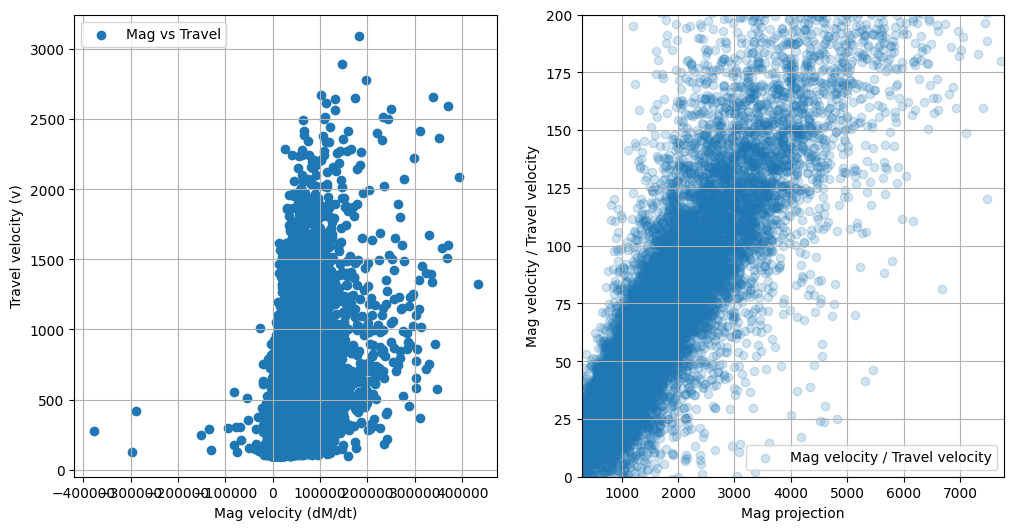

In [ ]:
# Mag velocity experiments
dm_dt = np.diff(mag_proj, prepend=mag_proj[0]) / dt_s

v_mask = v > 100
v_ratio = dm_dt[v_mask] / v[v_mask]

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(dm_dt[v_mask], v[v_mask], label="Mag vs Travel")
plt.xlabel("Mag velocity (dM/dt)")
plt.ylabel("Travel velocity (v)")
plt.legend()
plt.grid()
plt.subplot(1, 2, 2)
plt.scatter(mag_proj[v_mask], v_ratio, label="Mag velocity / Travel velocity", alpha=0.2)
plt.xlabel("Mag projection")
plt.ylabel("Mag velocity / Travel velocity")
plt.xlim(mag_lower_thresh - 500, mag_upper_thresh + 5000)
plt.ylim(0, 200)
plt.legend()
plt.grid()

(0.0, 10000.0)

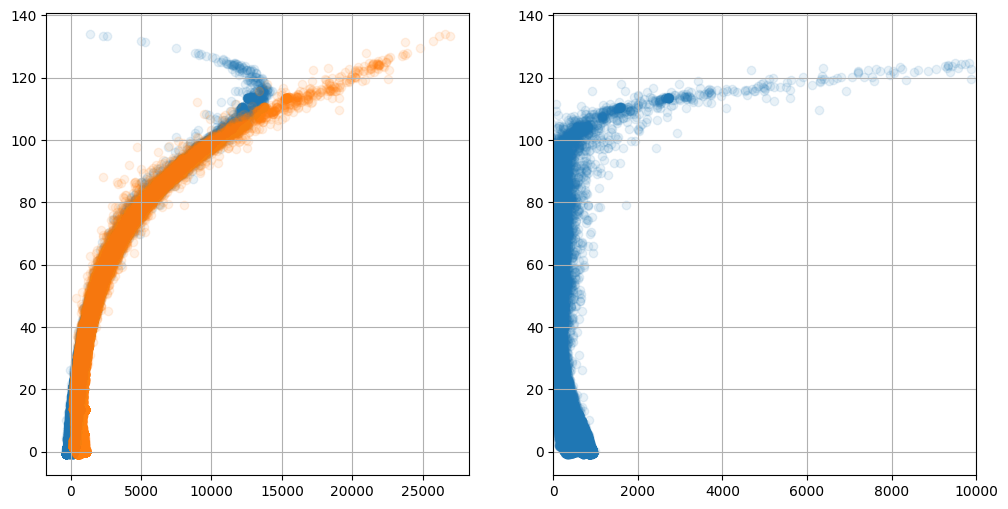

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(mag_proj, travel, alpha=0.1)
plt.scatter(mag_raw_mag, travel, alpha=0.1)
plt.grid()
plt.subplot(1, 2, 2)
plt.scatter(mag_raw_mag - mag_proj, travel, alpha=0.1)
plt.grid()
plt.xlim(0, 10000)

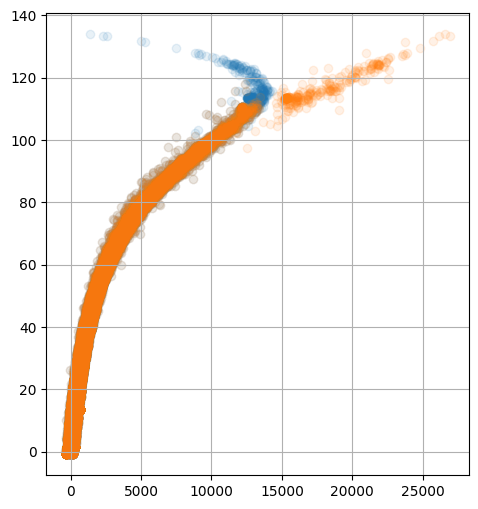

In [ ]:
bad_mag_mask = mag_raw_mag - mag_proj > 2000
corrected_mags = mag_proj.copy()
corrected_mags[bad_mag_mask] = mag_raw_mag[bad_mag_mask]

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(mag_proj, travel, alpha=0.1)
plt.scatter(corrected_mags, travel, alpha=0.1)
plt.grid()